In [27]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
!pip install phik
from phik import resources, report

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/nikitaLar-collab/Datasets/refs/heads/main/athletes.csv')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [30]:
df.describe()

,id,height,weight,gold,silver,bronze
count,1.153800e+04,11208.000000,10879.000000,11538.000000,11538.000000,11538.000000
mean,4.999885e+08,1.766282,72.068205,0.057722,0.056769,0.061016
std,2.908648e+08,0.112719,16.177334,0.255910,0.239147,0.243320
min,1.834700e+04,1.210000,31.000000,0.000000,0.000000,0.000000
25%,2.450997e+08,1.690000,60.000000,0.000000,0.000000,0.000000
50%,5.002011e+08,1.760000,70.000000,0.000000,0.000000,0.000000
75%,7.539874e+08,1.840000,81.000000,0.000000,0.000000,0.000000
max,9.999878e+08,2.210000,170.000000,5.000000,2.000000,2.000000


In [31]:
df.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


<Axes: >

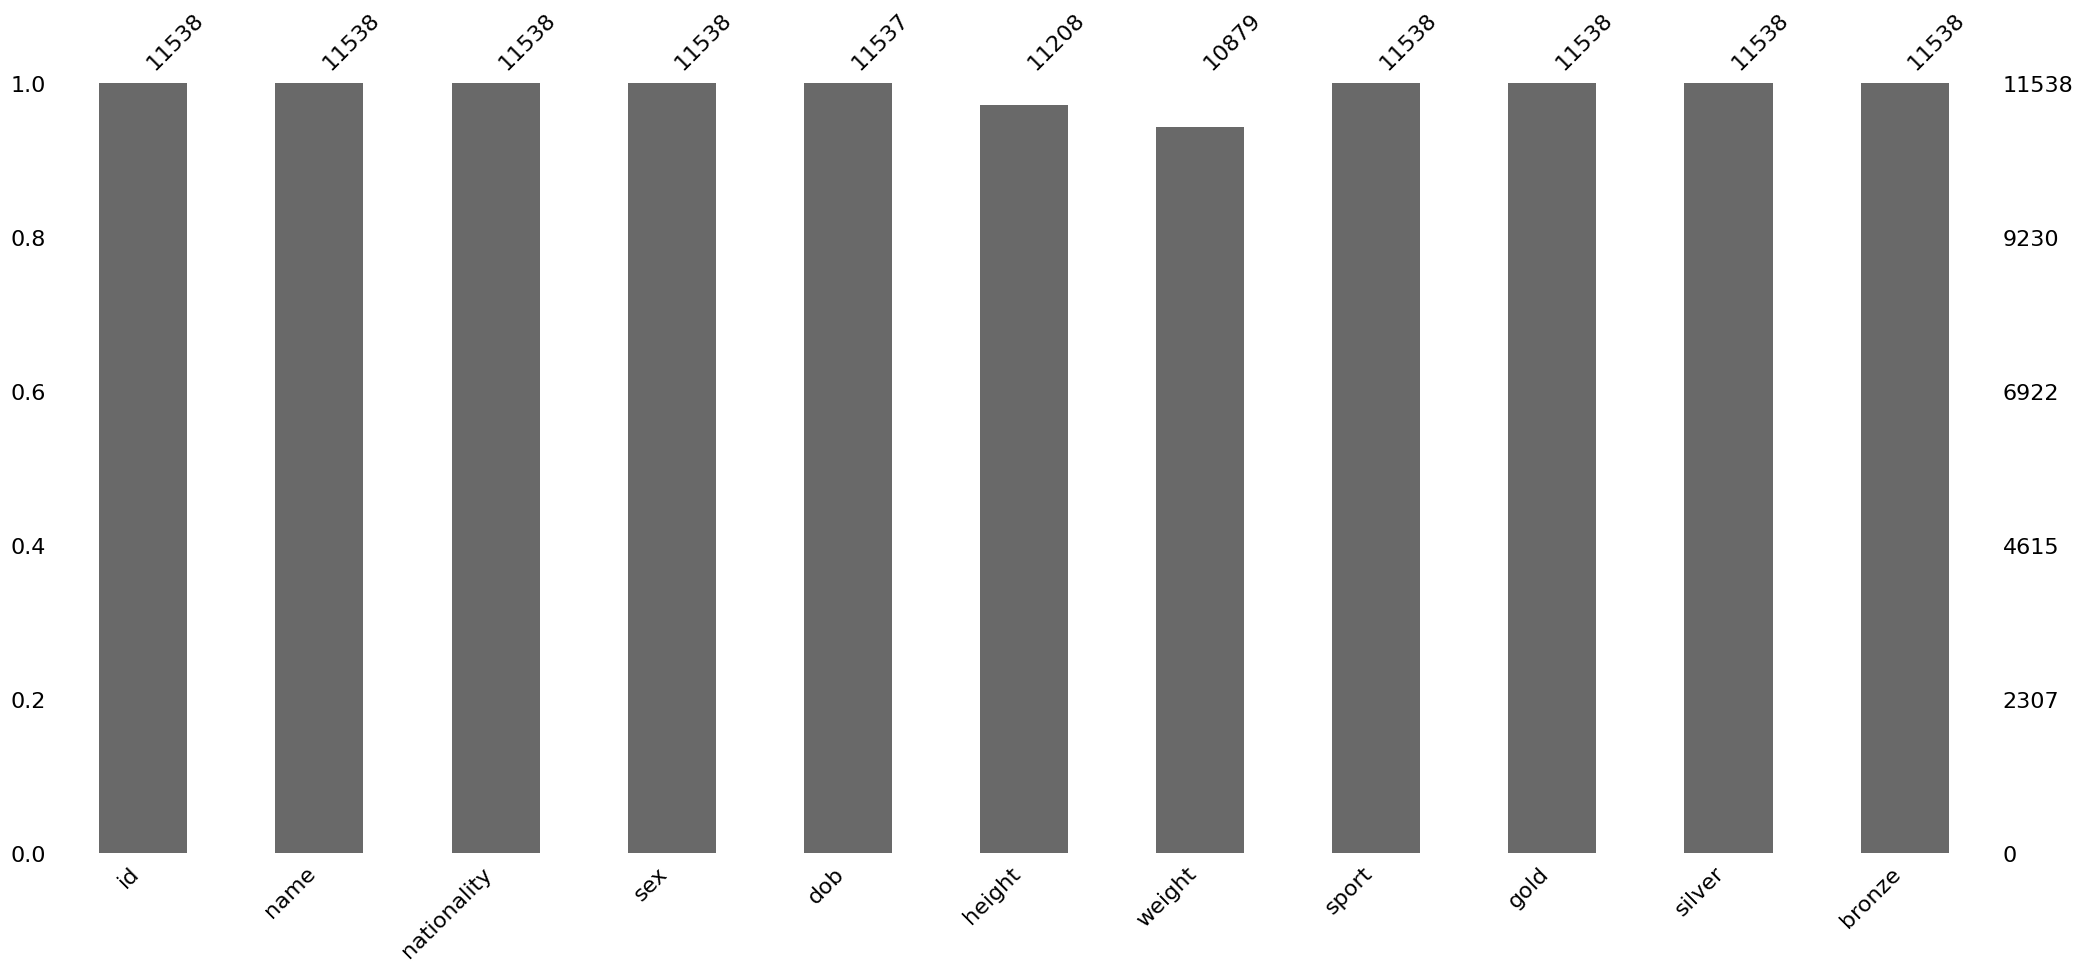

In [32]:
msno.bar(df)

<Axes: >

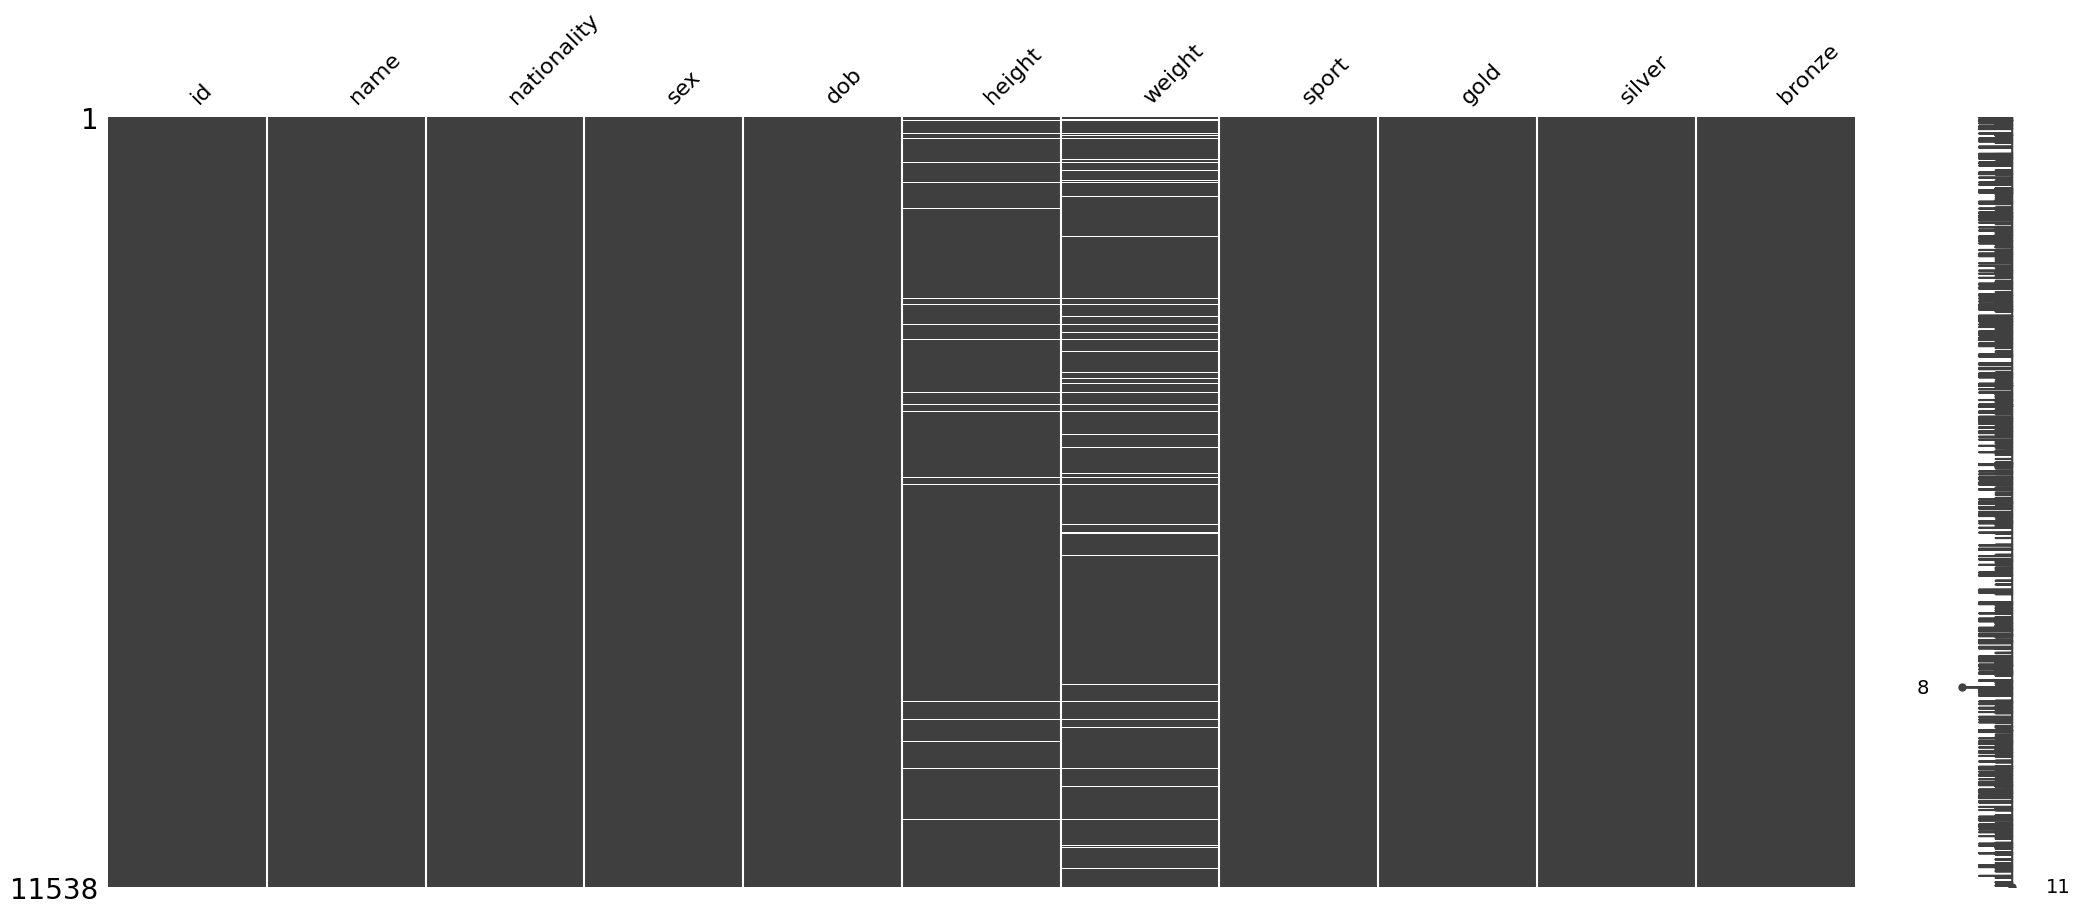

In [33]:
msno.matrix(df)

In [34]:
# Статистика пропусков
missing_stats = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isna().sum().values,
    'Доля (%)': (df.isna().mean() * 100).round(1).values
}).sort_values('Доля (%)', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)
missing_stats

,Колонка,Пропусков,Доля (%)
0,weight,659,5.7
1,height,330,2.9
2,id,0,0.0
3,nationality,0,0.0
4,name,0,0.0
5,dob,1,0.0
6,sex,0,0.0
7,sport,0,0.0
8,gold,0,0.0
9,silver,0,0.0


<Axes: >

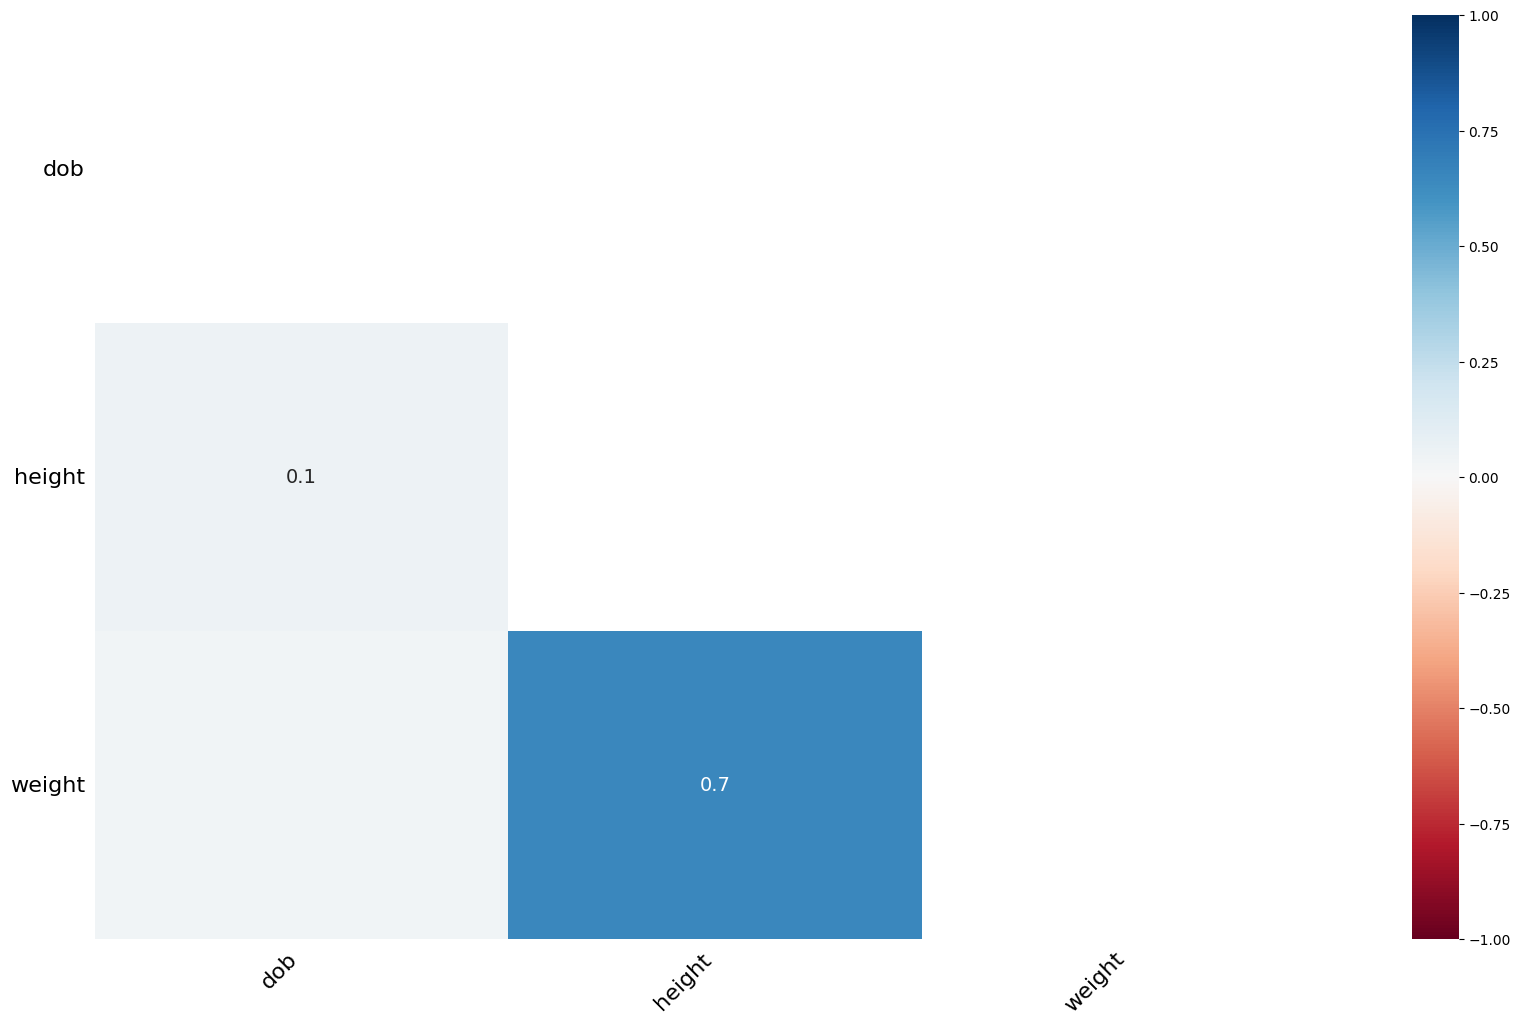

In [35]:
msno.heatmap(df)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [37]:
df['height_is_na'] = df['height'].isna()
df['weight_is_na'] = df['weight'].isna()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            11538 non-null  int64  
 1   name          11538 non-null  object 
 2   nationality   11538 non-null  object 
 3   sex           11538 non-null  object 
 4   dob           11537 non-null  object 
 5   height        11208 non-null  float64
 6   weight        10879 non-null  float64
 7   sport         11538 non-null  object 
 8   gold          11538 non-null  int64  
 9   silver        11538 non-null  int64  
 10  bronze        11538 non-null  int64  
 11  height_is_na  11538 non-null  bool   
 12  weight_is_na  11538 non-null  bool   
dtypes: bool(2), float64(2), int64(4), object(5)
memory usage: 1014.2+ KB


In [39]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['height',
    'weight',
    'gold',
    'silver',
    'bronze',
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df.drop(['id'], axis=1).phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable dob is large: 5595. Are you sure this is not an interval variable? Analysis for pairs of variables including dob can be slow.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable name is large: 11517. Are you sure this is not an interval variable? Analysis for pairs of variables including name can be slow.
  warnings.warn(


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.